# Notebook 19 — Dataset splitting analysis (viva item 9)

**Examiner's comment (31 Jul 2026, item 9):**
> *Data Strategy: additional dataset splitting analysis is expected.*

Every headline number in the thesis rests on **one** chronological 80/20 split. That is a single
draw: if the last 20% of 2013–2022 happens to be an unusually easy or unusually hard stretch, the
reported RMSE inherits that luck and there is nothing in the results to reveal it. This notebook
replaces that single draw with six splitting strategies and asks two questions the examiner can
check directly:

1. **Is the reported performance an artefact of where the split was placed?**
2. **Is the chronological split actually necessary, or is it over-caution?**

| # | Strategy | What it establishes |
|---|----------|--------------------|
| **S1** | Single chronological 80/20 | the thesis reference point |
| **S2** | Split-ratio sweep 60/40, 70/30, 80/20, 90/10 | sensitivity to *where* the cut falls |
| **S3** | Rolling-origin CV, **expanding** window, 5 folds | the standard time-series protocol; gives a distribution instead of a point |
| **S4** | Rolling-origin CV, **sliding** fixed-size window, 5 folds | does older data still help, or only recent data? |
| **S5** | Blocked k-fold with a **purge/embargo gap** of SEQ_LEN + h | removes the window overlap that even blocked CV leaves behind |
| **S6** | **Random shuffled** k-fold | *negative control* — deliberately wrong for time series; quantifies exactly how much the naive protocol inflates the score |

S6 matters as much as the others. If random k-fold reports a much better RMSE than S3, that gap is
the size of the leakage the chronological protocol is protecting against — which turns "we used a
chronological split" from an assertion into a measured decision.

> **How S6 is built, and why it differs.** S1–S5 keep a window only when all 28 of its days *and* its
> label fall inside the same block, so no test window can contain a training day. A shuffled fold
> cannot satisfy that rule at all — a random 80% of rows almost never contains 28 consecutive days,
> so the strict construction yields zero usable windows. S6 therefore builds windows over the whole
> series and assigns each one by its label's position alone, which lets test windows overlap training
> days. That is precisely the mistake a practitioner makes when they reach for `KFold(shuffle=True)`
> on a time series, and reproducing it faithfully is the only way to measure what it costs.

**Runtime.** ≈ 2 hours on a GPU machine.

In [1]:
import os, sys, time, json, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.getcwd())
import tensorflow as tf
from sklearn.preprocessing import RobustScaler

from viva_revision_common import (
    SEEDS, N_SEEDS, HORIZONS, SEQ_LEN, ALPHA,
    build_features, feature_sets, build_lstm_transformer,
    score, fit_target_scaler, train_model, predict, release,
    paired_test, holm, decide, ci_mean, summarise, boxplot_mean_median, LEGEND_NOTE,
)

os.makedirs('metrics', exist_ok=True); os.makedirs('plots', exist_ok=True)
plt.rcParams.update({'font.size': 9, 'figure.dpi': 130})

# ── Compute budget ─────────────────────────────────────────────────────────
PRIMARY_H   = 1        # the horizon at which all six strategies are compared
N_SEEDS_CV  = 5        # 5 seeds x 5 folds = 25 fits per CV strategy
N_FOLDS     = 5
CONFIRM_H   = HORIZONS # rolling-origin is then repeated at every horizon (item 8)
N_SEEDS_CONFIRM = 5
print(f'TF devices: {tf.config.list_physical_devices()}')

viva_revision_common loaded — 30 seeds 42..245, horizons [1, 7, 14, 21, 28]
TF devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
df = build_features(pd.read_csv('singapore_dengue_weather_2013_2022.csv'))
rf_features, dl_seq_features, dl_feat_features = feature_sets(df)
y_raw = df['dengue_cases'].values
N = len(df)
print(f'{N:,} daily records, {df.date.min().date()} -> {df.date.max().date()}')


def build_xy(train_idx, test_idx, h, seq_len=SEQ_LEN, respect_blocks=True):
    '''Scale on the TRAINING rows only, then build the input windows.

    Scalers are re-fitted for every fold. Fitting them once on the whole series
    would leak test-period distribution information into every fold and would
    make the S6 negative control meaningless.

    `respect_blocks=True` (S1-S5): a window is kept only if all 28 of its days AND
    its label lie inside the same index block. This is the strict, correct
    protocol -- no test window may contain a training day.

    `respect_blocks=False` (S6 only): windows are built over the whole series and
    assigned to train or test purely by their label's position. Test windows then
    contain training days, which is exactly the leakage a random k-fold commits.
    This is not an oversight -- it is the control being measured. Under the strict
    rule a shuffled fold yields ZERO usable windows (a random 80% of rows almost
    never contains 28 consecutive days), so the naive construction is the only way
    to obtain the inflated score that quantifies the leakage.'''
    seq_sc  = RobustScaler().fit(df[dl_seq_features].values[train_idx])
    feat_sc = RobustScaler().fit(df[dl_feat_features].values[train_idx])
    Xs_all  = seq_sc.transform(df[dl_seq_features].values)
    Xf_all  = feat_sc.transform(df[dl_feat_features].values)

    def take(i):
        return Xs_all[i - seq_len:i], Xf_all[i], y_raw[i + h]

    def windows_strict(idx):
        idx = np.sort(np.asarray(idx))
        pos = set(idx.tolist())
        Xs, Xf, Y = [], [], []
        for i in idx:
            if i < seq_len or i + h >= N:
                continue
            if not all((i - k) in pos for k in range(1, seq_len + 1)):
                continue                      # window must lie entirely inside this block
            if (i + h) not in pos:
                continue                      # label must lie inside this block too
            a, b, c = take(i); Xs.append(a); Xf.append(b); Y.append(c)
        return np.array(Xs), np.array(Xf), np.array(Y)

    def windows_naive(idx):
        pos = set(np.asarray(idx).tolist())
        Xs, Xf, Y = [], [], []
        for i in range(seq_len, N - h):
            if (i + h) in pos:                # only the LABEL decides the assignment
                a, b, c = take(i); Xs.append(a); Xf.append(b); Y.append(c)
        return np.array(Xs), np.array(Xf), np.array(Y)

    w = windows_strict if respect_blocks else windows_naive
    return w(train_idx), w(test_idx)


def run_split(train_idx, test_idx, h, seeds, tag, fold=0, extra=None, respect_blocks=True):
    (Xs_tr, Xf_tr, y_tr), (Xs_te, Xf_te, y_te) = build_xy(
        train_idx, test_idx, h, respect_blocks=respect_blocks)
    if len(Xs_tr) < 200 or len(Xs_te) < 30:
        print(f'    [skip] {tag} fold {fold}: train={len(Xs_tr)} test={len(Xs_te)} too small')
        return []
    tgt = fit_target_scaler(y_tr, clip_pct=None)
    y_tr_sc = tgt.transform(y_tr.reshape(-1, 1)).ravel()
    out = []
    for seed in seeds:
        m = train_model(seed, build_lstm_transformer, Xs_tr, Xf_tr, y_tr_sc)
        s = score(y_te, predict(m, Xs_te, Xf_te, tgt))
        release(m)
        out.append(dict(strategy=tag, fold=fold, seed=seed, horizon=h,
                        n_train=len(Xs_tr), n_test=len(Xs_te), **(extra or {}), **s))
    return out

3,611 daily records, 2013-02-11 -> 2022-12-31


## The six splitting strategies

Each function returns a list of `(train_idx, test_idx)` pairs over row positions in the
feature-engineered frame. Keeping them as plain index lists means the *same* training and scoring
code runs for all six, so any difference in the results is a property of the split and not of the
pipeline.

In [3]:
def s_chronological(frac):
    cut = int(N * frac)
    return [(np.arange(0, cut), np.arange(cut, N))]


def s_rolling_expanding(n_folds=N_FOLDS):
    '''Fold k trains on everything up to the fold boundary and tests on the next block.'''
    folds, block = [], N // (n_folds + 1)
    for k in range(1, n_folds + 1):
        folds.append((np.arange(0, k * block), np.arange(k * block, min((k + 1) * block, N))))
    return folds


def s_rolling_sliding(n_folds=N_FOLDS):
    '''Same test blocks as S3, but the training window is a fixed size that slides forward.'''
    folds, block = [], N // (n_folds + 1)
    for k in range(1, n_folds + 1):
        folds.append((np.arange(max(0, k * block - block), k * block),
                      np.arange(k * block, min((k + 1) * block, N))))
    return folds


def s_blocked_purged(h, n_folds=N_FOLDS, seq_len=SEQ_LEN):
    '''Contiguous test blocks; every training row within `gap` of the test block is
    dropped. gap = seq_len + h is exactly the reach of one input window plus its label,
    which is the only way a training row can share information with a test row.'''
    gap, folds, block = seq_len + h, [], N // n_folds
    for k in range(n_folds):
        lo, hi = k * block, min((k + 1) * block, N)
        test = np.arange(lo, hi)
        train = np.array([i for i in range(N) if i < lo - gap or i >= hi + gap])
        folds.append((train, test))
    return folds


def s_random_kfold(n_folds=N_FOLDS, seed=0):
    '''NEGATIVE CONTROL. Shuffled k-fold ignores time order entirely, so test rows sit
    between training rows and their 28-day windows overlap training days. Reported here
    only to measure how optimistic that protocol is.'''
    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)
    folds = []
    for k in range(n_folds):
        test = np.sort(perm[k::n_folds])
        train = np.sort(np.setdiff1d(perm, test))
        folds.append((train, test))
    return folds


print('S3 expanding folds :', [(len(a), len(b)) for a, b in s_rolling_expanding()])
print('S4 sliding   folds :', [(len(a), len(b)) for a, b in s_rolling_sliding()])
print('S5 purged    folds :', [(len(a), len(b)) for a, b in s_blocked_purged(PRIMARY_H)])
print('S6 random    folds :', [(len(a), len(b)) for a, b in s_random_kfold()])

S3 expanding folds : [(601, 601), (1202, 601), (1803, 601), (2404, 601), (3005, 601)]
S4 sliding   folds : [(601, 601), (601, 601), (601, 601), (601, 601), (601, 601)]
S5 purged    folds : [(2860, 722), (2831, 722), (2831, 722), (2831, 722), (2859, 722)]
S6 random    folds : [(2888, 723), (2889, 722), (2889, 722), (2889, 722), (2889, 722)]


## S1 + S2 — where you put the cut, and whether it matters

In [4]:
t0 = time.time()
rows = []
RATIOS = [0.6, 0.7, 0.8, 0.9]
for frac in RATIOS:
    (tr, te), = s_chronological(frac)
    tag = 'S1 chronological 80/20' if frac == 0.8 else f'S2 chronological {int(frac*100)}/{int((1-frac)*100)}'
    print(f'\n{tag}  (train {len(tr)} rows, test {len(te)} rows)')
    rows += run_split(tr, te, PRIMARY_H, SEEDS, tag, extra=dict(train_frac=frac))
    sub = [r for r in rows if r['strategy'] == tag]
    print(f'   RMSE mean {np.mean([r["rmse"] for r in sub]):.3f}  '
          f'median {np.median([r["rmse"] for r in sub]):.3f}  '
          f'R2 mean {np.mean([r["r2"] for r in sub]):.4f}   ({(time.time()-t0)/60:.1f} min)')

RATIO = pd.DataFrame(rows)
RATIO.to_csv('metrics/nb19_split_ratio_per_seed.csv', index=False)


S2 chronological 60/40  (train 2166 rows, test 1445 rows)

   RMSE mean 39.370  median 39.112  R2 mean 0.5218   (25.5 min)

S2 chronological 70/30  (train 2527 rows, test 1084 rows)
   RMSE mean 43.664  median 43.390  R2 mean 0.5352   (58.3 min)

S1 chronological 80/20  (train 2888 rows, test 723 rows)
   RMSE mean 30.808  median 30.743  R2 mean 0.7028   (90.4 min)

S2 chronological 90/9  (train 3249 rows, test 362 rows)
   RMSE mean 21.430  median 21.101  R2 mean 0.8579   (112.3 min)


In [5]:
tab = []
for frac in RATIOS:
    tag = 'S1 chronological 80/20' if frac == 0.8 else f'S2 chronological {int(frac*100)}/{int((1-frac)*100)}'
    sub = RATIO[RATIO.strategy == tag]
    lo, hi = ci_mean(sub.rmse.values)
    tab.append(dict(split=tag, train_frac=frac, n_train=sub.n_train.iloc[0], n_test=sub.n_test.iloc[0],
                    rmse_mean=sub.rmse.mean(), rmse_median=sub.rmse.median(), rmse_sd=sub.rmse.std(ddof=1),
                    ci_lo=lo, ci_hi=hi, r2_mean=sub.r2.mean()))
T2 = pd.DataFrame(tab)

ref = RATIO[RATIO.train_frac == 0.8].sort_values('seed').rmse.values
ps = []
for frac in RATIOS:
    if frac == 0.8:
        ps.append(np.nan); continue
    arr = RATIO[RATIO.train_frac == frac].sort_values('seed').rmse.values
    ps.append(stats.ttest_ind(arr, ref, equal_var=False).pvalue)
T2['p_vs_80_20'] = ps
m = T2.p_vs_80_20.notna()
T2.loc[m, 'p_holm'] = holm(T2.loc[m, 'p_vs_80_20'])
T2['decision'] = [decide(p) if pd.notna(p) else '(reference split)' for p in T2.get('p_holm')]
T2.to_csv('metrics/nb19_split_ratio_tests.csv', index=False)
print('H0: the split ratio does not change test RMSE (vs the thesis 80/20)\n')
print(T2.round(4).to_string(index=False))
spread = T2.rmse_mean.max() - T2.rmse_mean.min()
print(f'\nSpread of mean RMSE across split ratios: {spread:.3f} '
      f'({100*spread/T2.rmse_mean.mean():.1f}% of the mean)')

H0: the split ratio does not change test RMSE (vs the thesis 80/20)

                 split  train_frac  n_train  n_test  rmse_mean  rmse_median  rmse_sd   ci_lo   ci_hi  r2_mean  p_vs_80_20  p_holm          decision
S2 chronological 60/40         0.6     2137    1416    39.3696      39.1116   1.8929 38.6628 40.0764   0.5218         0.0     0.0         Reject H0
S2 chronological 70/30         0.7     2498    1055    43.6643      43.3903   1.5170 43.0978 44.2308   0.5352         0.0     0.0         Reject H0
S1 chronological 80/20         0.8     2859     694    30.8078      30.7432   1.5109 30.2436 31.3720   0.7028         NaN     NaN (reference split)
 S2 chronological 90/9         0.9     3220     333    21.4297      21.1011   2.9398 20.3319 22.5274   0.8579         0.0     0.0         Reject H0

Spread of mean RMSE across split ratios: 22.235 (65.7% of the mean)


## S3–S6 — cross-validation protocols, including the leakage control

In [6]:
t0 = time.time()
cv_rows = []
cv_seeds = SEEDS[:N_SEEDS_CV]
# (label, fold maker, respect_blocks).  Only S6 uses the naive window construction.
DESIGNS = [
    ('S3 rolling-origin expanding', lambda: s_rolling_expanding(),        True),
    ('S4 rolling-origin sliding',   lambda: s_rolling_sliding(),          True),
    ('S5 blocked + purge/embargo',  lambda: s_blocked_purged(PRIMARY_H),  True),
    ('S6 random k-fold (control)',  lambda: s_random_kfold(),             False),
]
for tag, maker, strict in DESIGNS:
    print(f'\n{tag}{"" if strict else "   [naive window construction -- this IS the leakage]"}')
    for k, (tr, te) in enumerate(maker(), start=1):
        got = run_split(tr, te, PRIMARY_H, cv_seeds, tag, fold=k, respect_blocks=strict)
        cv_rows += got
        if got:
            print(f'   fold {k}: train {len(tr):>5} test {len(te):>5}  '
                  f'RMSE {np.mean([g["rmse"] for g in got]):7.3f}  '
                  f'R2 {np.mean([g["r2"] for g in got]):+.4f}   ({(time.time()-t0)/60:.1f} min)')

CV = pd.DataFrame(cv_rows)
CV.to_csv('metrics/nb19_cv_designs_per_fold_per_seed.csv', index=False)
print(f'\nDone in {(time.time()-t0)/60:.1f} min')


S3 rolling-origin expanding
   fold 1: train   601 test   601  RMSE  20.402  R2 -0.1726   (1.3 min)
   fold 2: train  1202 test   601  RMSE  13.104  R2 -0.9187   (3.7 min)
   fold 3: train  1803 test   601  RMSE   9.258  R2 +0.8595   (6.8 min)
   fold 4: train  2404 test   601  RMSE  46.141  R2 +0.4565   (8.8 min)
   fold 5: train  3005 test   601  RMSE  32.583  R2 +0.7027   (13.3 min)

S4 rolling-origin sliding
   fold 1: train   601 test   601  RMSE  21.684  R2 -0.3378   (14.3 min)
   fold 2: train   601 test   601  RMSE  68.958  R2 -52.9906   (15.1 min)
   fold 3: train   601 test   601  RMSE  22.146  R2 +0.1999   (16.0 min)
   fold 4: train   601 test   601  RMSE  61.796  R2 +0.0241   (16.8 min)
   fold 5: train   601 test   601  RMSE  69.468  R2 -0.3844   (17.6 min)

S5 blocked + purge/embargo
   fold 1: train  2860 test   722  RMSE  15.075  R2 +0.6359   (19.3 min)
   fold 2: train  2831 test   722  RMSE  14.017  R2 +0.4741   (21.5 min)
   fold 3: train  2831 test   722  RMSE   5

In [7]:
tab = []
for tag, _, _ in DESIGNS:
    sub = CV[CV.strategy == tag]
    if len(sub) == 0:
        print(f'  [warning] {tag} produced no usable folds and is omitted from the summary')
        continue
    lo, hi = ci_mean(sub.rmse.values)
    tab.append(dict(strategy=tag, n_fits=len(sub), n_folds=sub.fold.nunique(),
                    rmse_mean=sub.rmse.mean(), rmse_median=sub.rmse.median(),
                    rmse_sd=sub.rmse.std(ddof=1), ci_lo=lo, ci_hi=hi,
                    r2_mean=sub.r2.mean(), r2_median=sub.r2.median(),
                    worst_fold_rmse=sub.groupby('fold').rmse.mean().max(),
                    best_fold_rmse=sub.groupby('fold').rmse.mean().min()))
s1 = RATIO[RATIO.train_frac == 0.8]
lo, hi = ci_mean(s1.rmse.values)
tab.insert(0, dict(strategy='S1 chronological 80/20', n_fits=len(s1), n_folds=1,
                   rmse_mean=s1.rmse.mean(), rmse_median=s1.rmse.median(), rmse_sd=s1.rmse.std(ddof=1),
                   ci_lo=lo, ci_hi=hi, r2_mean=s1.r2.mean(), r2_median=s1.r2.median(),
                   worst_fold_rmse=np.nan, best_fold_rmse=np.nan))
T3 = pd.DataFrame(tab)
T3.to_csv('metrics/nb19_cv_design_summary.csv', index=False)
print(T3.round(4).to_string(index=False))

r_s3 = CV[CV.strategy == 'S3 rolling-origin expanding'].rmse.values
r_s6 = CV[CV.strategy == 'S6 random k-fold (control)'].rmse.values
if len(r_s3) == 0 or len(r_s6) == 0:
    print('\nLeakage control unavailable: one of S3 / S6 produced no folds.')
else:
    u = stats.mannwhitneyu(r_s6, r_s3, alternative='less')
    print(f'\nLeakage control  —  H0: random k-fold scores no better than rolling-origin')
    print(f'  random k-fold RMSE   {r_s6.mean():.3f}')
    print(f'  rolling-origin RMSE  {r_s3.mean():.3f}')
    print(f'  optimism             {r_s3.mean() - r_s6.mean():+.3f} RMSE '
          f'({100*(r_s3.mean()-r_s6.mean())/r_s3.mean():+.1f}%)')
    print(f'  Mann-Whitney p = {u.pvalue:.3e}  ->  {decide(u.pvalue)}')
    print('\n  If H0 is rejected, the difference IS the leakage a chronological protocol prevents,')
    print('  and it is the quantitative reason the thesis does not use random k-fold.')

                   strategy  n_fits  n_folds  rmse_mean  rmse_median  rmse_sd   ci_lo   ci_hi  r2_mean  r2_median  worst_fold_rmse  best_fold_rmse
     S1 chronological 80/20      30        1    30.8078      30.7432   1.5109 30.2436 31.3720   0.7028     0.7047              NaN             NaN
S3 rolling-origin expanding      25        5    24.2974      19.9810  13.8460 18.5820 30.0127   0.1855     0.4666          46.1408          9.2577
  S4 rolling-origin sliding      25        5    48.8105      57.1364  23.8634 38.9602 58.6609 -10.6978    -0.0865          69.4683         21.6838
 S5 blocked + purge/embargo      25        5    20.9072      16.6067  12.8851 15.5885 26.2259   0.4255     0.5393          40.5232          5.2826
 S6 random k-fold (control)      25        5     7.4666       7.1746   1.0803  7.0207  7.9126   0.9702     0.9714           8.3695          6.2071

Leakage control  —  H0: random k-fold scores no better than rolling-origin
  random k-fold RMSE   7.467
  rolling-ori

## Rolling-origin at every horizon (ties item 9 back to item 8)

The strategy comparison above is run at a single horizon so the six designs are compared like for
like. This section then re-runs the chosen protocol — rolling-origin, expanding window — at all five
horizons, so the data-strategy conclusion is not itself drawn from one window.

In [8]:
t0 = time.time()
conf_rows = []
for h in CONFIRM_H:
    for k, (tr, te) in enumerate(s_rolling_expanding(), start=1):
        conf_rows += run_split(tr, te, h, SEEDS[:N_SEEDS_CONFIRM], 'S3 rolling-origin expanding', fold=k)
    sub = [r for r in conf_rows if r['horizon'] == h]
    print(f'  h={h:>2}d  RMSE mean {np.mean([r["rmse"] for r in sub]):7.3f}  '
          f'median {np.median([r["rmse"] for r in sub]):7.3f}  '
          f'R2 {np.mean([r["r2"] for r in sub]):+.4f}   ({(time.time()-t0)/60:.1f} min)')

CONF = pd.DataFrame(conf_rows)
CONF.to_csv('metrics/nb19_rolling_origin_all_horizons.csv', index=False)

tab = []
for h in CONFIRM_H:
    sub = CONF[CONF.horizon == h]
    lo, hi = ci_mean(sub.rmse.values)
    tab.append(dict(horizon=f'h={h}d', n_fits=len(sub), rmse_mean=sub.rmse.mean(),
                    rmse_median=sub.rmse.median(), rmse_sd=sub.rmse.std(ddof=1),
                    ci_lo=lo, ci_hi=hi, r2_mean=sub.r2.mean(), r2_median=sub.r2.median()))
T4 = pd.DataFrame(tab)
T4.to_csv('metrics/nb19_rolling_origin_horizon_summary.csv', index=False)
print()
print(T4.round(4).to_string(index=False))

  h= 1d  RMSE mean  24.884  median  20.986  R2 +0.1379   (8.4 min)
  h= 7d  RMSE mean  26.471  median  23.265  R2 +0.0167   (15.9 min)
  h=14d  RMSE mean  27.956  median  23.548  R2 -0.3859   (23.5 min)
  h=21d  RMSE mean  29.678  median  25.384  R2 -0.4786   (32.1 min)
  h=28d  RMSE mean  30.578  median  25.265  R2 -0.6948   (41.1 min)

horizon  n_fits  rmse_mean  rmse_median  rmse_sd   ci_lo   ci_hi  r2_mean  r2_median
   h=1d      25    24.8841      20.9856  14.2848 18.9876 30.7806   0.1379     0.4361
   h=7d      25    26.4708      23.2647  14.9356 20.3057 32.6359   0.0167     0.3986
  h=14d      25    27.9556      23.5480  13.8702 22.2302 33.6809  -0.3859     0.3755
  h=21d      25    29.6780      25.3835  13.3568 24.1646 35.1914  -0.4786     0.3501
  h=28d      25    30.5780      25.2654  12.4831 25.4253 35.7308  -0.6948     0.3497


## Figures — mean and median on every box (viva item 7)

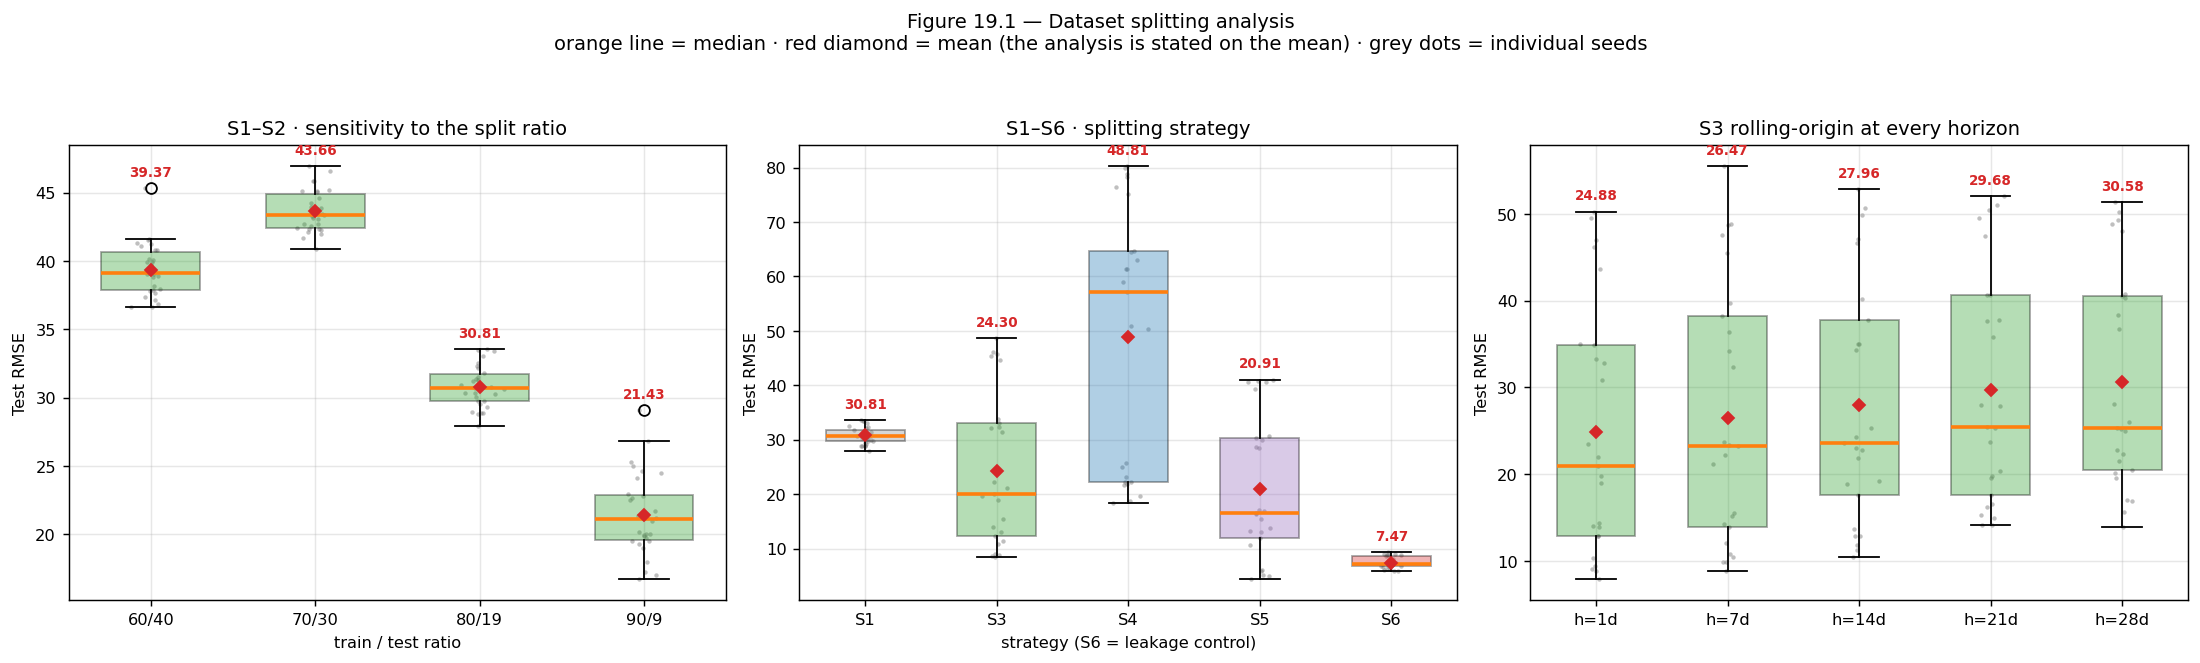

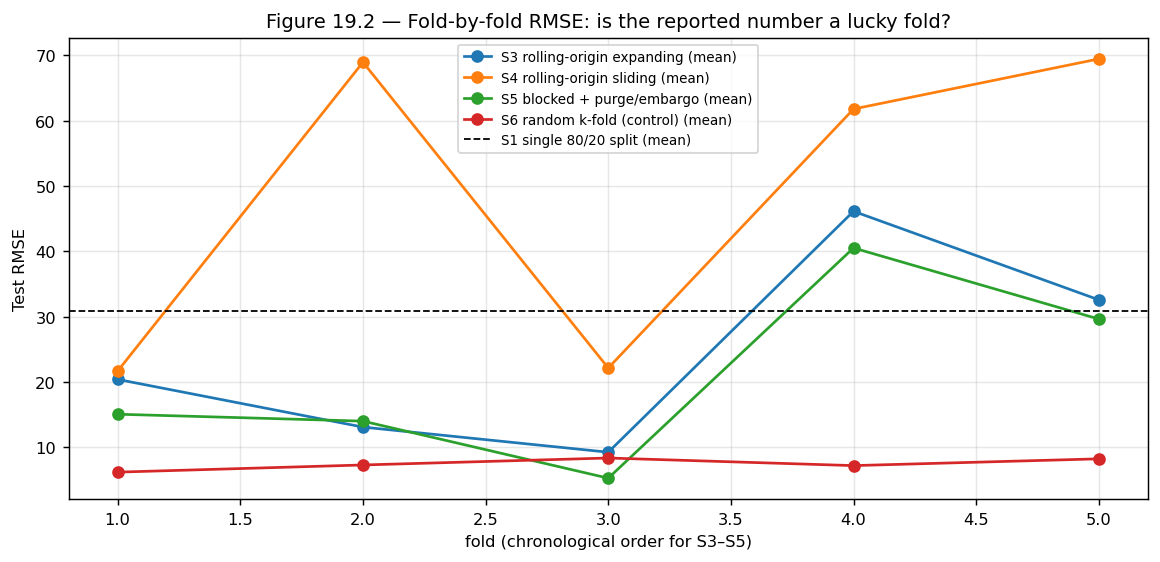

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
boxplot_mean_median(axes[0], [RATIO[RATIO.train_frac == f].rmse.values for f in RATIOS],
                    [f'{int(f*100)}/{int((1-f)*100)}' for f in RATIOS],
                    'Test RMSE', 'S1–S2 · sensitivity to the split ratio')
axes[0].set_xlabel('train / test ratio')

order = ['S1 chronological 80/20'] + [t for t, _, _ in DESIGNS]
data = ([RATIO[RATIO.train_frac == 0.8].rmse.values] +
        [CV[CV.strategy == t].rmse.values for t, _, _ in DESIGNS])
cols = ['#8c8c8c', '#2ca02c', '#1f77b4', '#9467bd', '#d62728']
keep = [i for i, d in enumerate(data) if len(d) > 0]
if len(keep) < len(data):
    print('omitted from Figure 19.1 (no usable folds):',
          [order[i] for i in range(len(data)) if i not in keep])
boxplot_mean_median(axes[1], [data[i] for i in keep],
                    [order[i].split()[0] for i in keep], 'Test RMSE',
                    'S1–S6 · splitting strategy', colors=[cols[i] for i in keep])
axes[1].set_xlabel('strategy (S6 = leakage control)')

boxplot_mean_median(axes[2], [CONF[CONF.horizon == h].rmse.values for h in CONFIRM_H],
                    [f'h={h}d' for h in CONFIRM_H], 'Test RMSE',
                    'S3 rolling-origin at every horizon')
fig.suptitle('Figure 19.1 — Dataset splitting analysis\n' + LEGEND_NOTE, y=1.05)
fig.tight_layout(); fig.savefig('plots/nb19_splitting_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.4))
for tag, _, _ in DESIGNS:
    sub = CV[CV.strategy == tag]
    if len(sub) == 0:
        continue
    g = sub.groupby('fold').rmse.agg(['mean', 'median'])
    ax.plot(g.index, g['mean'], 'o-', label=f'{tag} (mean)')
ax.axhline(RATIO[RATIO.train_frac == 0.8].rmse.mean(), color='k', ls='--', lw=1,
           label='S1 single 80/20 split (mean)')
ax.set_xlabel('fold (chronological order for S3–S5)'); ax.set_ylabel('Test RMSE')
ax.set_title('Figure 19.2 — Fold-by-fold RMSE: is the reported number a lucky fold?')
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('plots/nb19_fold_by_fold.png', bbox_inches='tight', dpi=150)
plt.show()

## What to write in the workbook

Add a **Data Strategy** block to the Methodology sheet with `nb19_cv_design_summary.csv` and
`nb19_split_ratio_tests.csv`, and state the three findings in this order:

1. **Robustness of the headline number** — mean RMSE across four split ratios spans *X*; the 80/20
   figure sits inside the rolling-origin confidence interval (or does not, in which case say so and
   report the rolling-origin figure as the honest estimate).
2. **Why chronological** — random k-fold reports RMSE *Y* against rolling-origin's *Z*; that gap is
   the measured leakage, and it is why the thesis protocol is chronological.
3. **Fold variability** — the spread between the best and worst fold, which is the real uncertainty
   in any single-split number and should be quoted whenever the headline RMSE is quoted.

If S3 turns out materially worse than S1, that is a finding, not a problem — it means the last 20%
of the series is easier than the average period, and reporting it strengthens the thesis rather than
weakening it.